# Mesh-Independence Validation

A mesh-independence study was performed on the baseline aluminium heat-sink model to verify that the predicted maximum temperature was not significantly affected by mesh refinement.

All geometry, materials, thermal loads and boundary conditions were held constant while only the global element size was changed.

Three mesh levels were evaluated:

- **Coarse:** 5.0 mm
- **Medium:** 2.5 mm
- **Fine:** 2.0 mm

The maximum steady-state temperature obtained from each simulation was recorded.

A change of less than **2%** between successive mesh refinements was adopted as the project mesh-independence criterion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mesh_results = pd.DataFrame({
    "Mesh": ["Coarse", "Medium", "Fine"],
    "Global Element Size (mm)": [5.0, 2.5, 2.0],
    "Maximum Temperature (°C)": [30.628, 30.631, 30.633]
})

# Percentage change relative to the previous mesh
mesh_results["Change from Previous (%)"] = (
    mesh_results["Maximum Temperature (°C)"]
    .pct_change()
    .abs()
    * 100
)

mesh_results.round(4)

,Mesh,Global Element Size (mm),Maximum Temperature (°C),Change from Previous (%)
0,Coarse,5.0,30.628,NaN
1,Medium,2.5,30.631,0.0098
2,Fine,2.0,30.633,0.0065


In [2]:
coarse_to_fine_change = (
    abs(
        mesh_results.loc[2, "Maximum Temperature (°C)"]
        - mesh_results.loc[0, "Maximum Temperature (°C)"]
    )
    / mesh_results.loc[0, "Maximum Temperature (°C)"]
    * 100
)

medium_to_fine_change = mesh_results.loc[2, "Change from Previous (%)"]

print(f"Coarse-to-fine temperature change: {coarse_to_fine_change:.4f}%")
print(f"Medium-to-fine temperature change: {medium_to_fine_change:.4f}%")
print("Mesh-independence criterion: < 2%")

Coarse-to-fine temperature change: 0.0163%
Medium-to-fine temperature change: 0.0065%
Mesh-independence criterion: < 2%


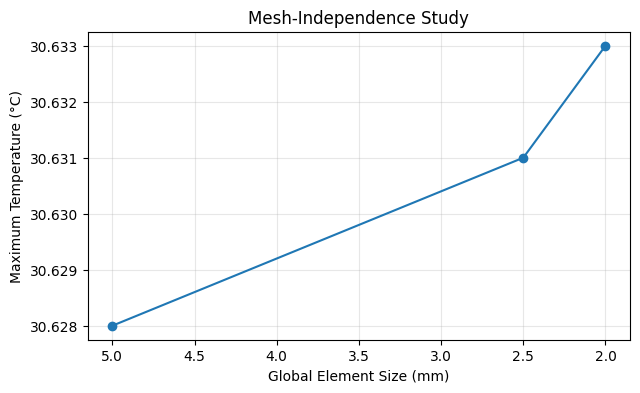

In [3]:
plt.figure(figsize=(7, 4))

plt.plot(
    mesh_results["Global Element Size (mm)"],
    mesh_results["Maximum Temperature (°C)"],
    marker="o"
)

plt.xlabel("Global Element Size (mm)")
plt.ylabel("Maximum Temperature (°C)")
plt.title("Mesh-Independence Study")

plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

### Mesh-Independence Result

The predicted maximum temperature changed only slightly as the mesh was refined:

- **5.0 mm mesh:** 30.628°C
- **2.5 mm mesh:** 30.631°C
- **2.0 mm mesh:** 30.633°C

The change from the medium to fine mesh was approximately **0.0065%**, while the total difference between the coarse and fine meshes was approximately **0.0163%**.

Both values are substantially below the predefined **2% mesh-independence criterion**. The thermal solution can therefore be considered effectively mesh-independent over the tested range.

A further refinement to **1.25 mm** was attempted, but the resulting node and element count exceeded the Ansys Student solver limit. This does not affect the convergence conclusion because the temperature had already stabilised well before this refinement.

The **2.5 mm medium mesh** was therefore selected for the remaining simulations as a suitable compromise between computational cost and numerical accuracy.